In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
df = pd.read_csv("minist.csv")

df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df = df.sample(n=5000, random_state=42)

print(df.shape)

(5000, 785)


In [6]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [7]:
print(X.shape)
print(y.shape)

(5000, 784)
(5000,)


In [8]:
X = X.reshape(-1, 28, 28, 1)

print(X.shape)

(5000, 28, 28, 1)


In [9]:
X = X.astype("float32") / 255.0

In [10]:
print(X.min())
print(X.max())

0.0
1.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 28, 28, 1)
X_test : (1000, 28, 28, 1)
y_train: (4000,)
y_test : (1000,)


In [13]:
n_classes = len(np.unique(y))

print("Number of classes:", n_classes)

Number of classes: 3


In [14]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(n_classes, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,475 (474.51 KB)

 Trainable params: 121,475 (474.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9344 - loss: 0.1823 - val_accuracy: 0.9887 - val_loss: 0.0347
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9884 - loss: 0.0392 - val_accuracy: 0.9937 - val_loss: 0.0276
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9909 - loss: 0.0249 - val_accuracy: 0.9912 - val_loss: 0.0270
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9925 - loss: 0.0200 - val_accuracy: 0.9950 - val_loss: 0.0246
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9962 - loss: 0.0108 - val_accuracy: 0.9912 - val_loss: 0.0298


In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9930 - loss: 0.0260
Test Accuracy: 0.9929999709129333
Test Accuracy: 99.30%


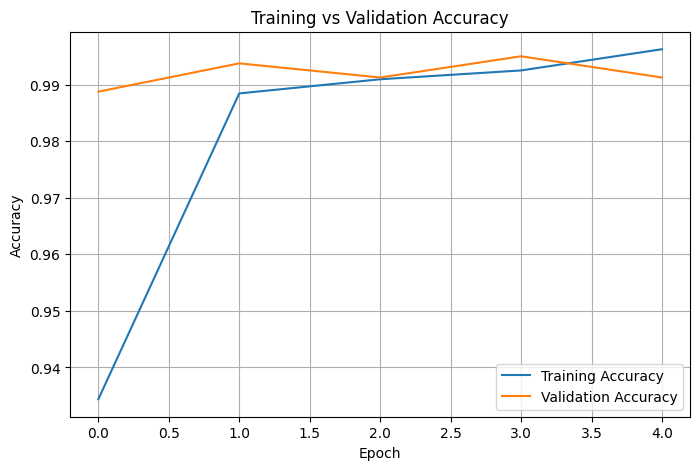

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [20]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [21]:
letters = [chr(i + 65) for i in range(26)]

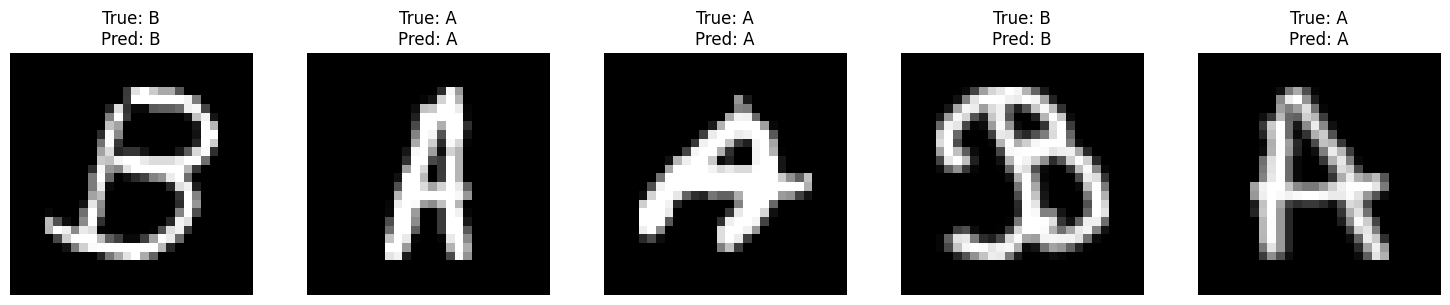

In [22]:
plt.figure(figsize=(15, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    true_label = letters[y_test[i]]
    predicted_label = letters[y_pred[i]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()